<a href="https://colab.research.google.com/github/raghavrakesh20/Basic-Python-programing-/blob/main/Week_one_Creating_word_cloud_and_sentiment_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Created a word cloud from the text of 'Frankenstein' scraped from Project Gutenberg. This involved scraping the text, preprocessing it (removing punctuation, numbers, converting to lowercase, and potentially removing stopwords), and then generating and displaying the word cloud and sentiment analysis.

In [1]:
import requests
from bs4 import BeautifulSoup

# URL for 'Frankenstein' on Project Gutenberg (plain text version)
# This URL is for the plain text UTF-8 version
url = "https://www.gutenberg.org/files/84/84-0.txt"

try:
    # Send an HTTP GET request to the URL
    response = requests.get(url)
    response.raise_for_status() # Raise an exception for HTTP errors

    # Project Gutenberg sometimes serves plain text directly, no BeautifulSoup needed if it's pure text.
    # Check content-type header
    if 'text/plain' in response.headers.get('Content-Type', ''):
        frankenstein_text = response.text
        print("Successfully downloaded plain text. First 500 characters:")
        print(frankenstein_text[:500])
    else:
        # If it's HTML, parse it with BeautifulSoup
        print("Content-Type is not plain text, attempting to parse as HTML.")
        soup = BeautifulSoup(response.content, 'html.parser')

        # Inspect the HTML to find the main text content.
        # Project Gutenberg often puts the book content within <pre> tags or a div with a specific class/id.
        # For many plain text versions linked from Gutenberg, the raw text is directly served.
        # Let's try to find potential content holders if it's HTML.
        # Common patterns: <pre>, <div class="contents">, <div id="content">

        # First, try to find <pre> tags, which are often used for plain text display
        pre_tags = soup.find_all('pre')
        if pre_tags:
            frankenstein_text = '\n'.join([pre.get_text() for pre in pre_tags])
        else:
            # If no pre tags, look for a div that might contain the text
            content_div = soup.find('div', class_='contents') or soup.find('div', id='content')
            if content_div:
                frankenstein_text = content_div.get_text()
            else:
                # Fallback: just get all visible text if specific tags aren't found
                frankenstein_text = soup.get_text()

        print("Successfully parsed HTML. First 500 characters of extracted text:")
        print(frankenstein_text[:500])

except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")
    frankenstein_text = None

if frankenstein_text:
    print(f"Total characters scraped: {len(frankenstein_text)}")

Successfully downloaded plain text. First 500 characters:
*** START OF THE PROJECT GUTENBERG EBOOK 84 ***

Frankenstein;

or, the Modern Prometheus

by Mary Wollstonecraft (Godwin) Shelley


 CONTENTS

 Letter 1
 Letter 2
 Letter 3
 Letter 4
 Chapter 1
 Chapter 2
 Chapter 3
 Chapter 4
 Chapter 5
 Chapter 6
 Chapter 7
 Chapter 8
 Chapter 9
 Chapter 10
 Chapter 11
 Chapter 12
 Chapter 13
 Chapter 14
 Chapter 15
 Chapter 16
 Chapter 17
 Chapter 18
 Chapter 19
 Chapter 20
 Chapter 21
 Chapter 22
 Chapter 23
 Chapter 24




Letter 1

_To Mrs. Saville, Engla
Total characters scraped: 419434


## Preprocess text

### Subtask:
Clean the scraped text by removing punctuation, numbers, converting to lowercase, and potentially removing common stopwords.


**Reasoning**:
To preprocess the text, I need to import relevant libraries (`string`, `re`, `nltk`), convert the text to lowercase, remove punctuation and numbers, and then remove common English stopwords. The `nltk` stopwords corpus needs to be downloaded first, and then the text cleaning operations will be applied sequentially.



In [2]:
import string
import re
import nltk

# Download NLTK stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

# 1. Convert to lowercase
cleaned_text = frankenstein_text.lower()

# 2. Remove punctuation
# Create a translation table to replace punctuation with spaces
punctuation_translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
cleaned_text = cleaned_text.translate(punctuation_translator)

# 3. Remove numbers
cleaned_text = re.sub(r'\d+', '', cleaned_text)

# 4. Remove common English stopwords
stop_words = set(stopwords.words('english'))

# Split text into words, filter out stopwords, and join back
words = cleaned_text.split()
filtered_words = [word for word in words if word not in stop_words]
cleaned_text = ' '.join(filtered_words)

print(f"Original text length: {len(frankenstein_text)}")
print(f"Cleaned text length: {len(cleaned_text)}")
print("First 500 characters of cleaned text:")
print(cleaned_text[:500])

AttributeError: module 'nltk.downloader' has no attribute 'DownloadError'

**Reasoning**:
The previous code failed because the `stopwords` corpus was not found, raising a `LookupError`, and the exception handling for `nltk.downloader.DownloadError` was incorrect. I need to catch `LookupError` when checking for the corpus and then call `nltk.download('stopwords')` if it's not found.



In [3]:
import string
import re
import nltk

# Download NLTK stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

# 1. Convert to lowercase
cleaned_text = frankenstein_text.lower()

# 2. Remove punctuation
# Create a translation table to replace punctuation with spaces
punctuation_translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
cleaned_text = cleaned_text.translate(punctuation_translator)

# 3. Remove numbers
cleaned_text = re.sub(r'\d+', '', cleaned_text)

# 4. Remove common English stopwords
stop_words = set(stopwords.words('english'))

# Split text into words, filter out stopwords, and join back
words = cleaned_text.split()
filtered_words = [word for word in words if word not in stop_words]
cleaned_text = ' '.join(filtered_words)

print(f"Original text length: {len(frankenstein_text)}")
print(f"Cleaned text length: {len(cleaned_text)}")
print("First 500 characters of cleaned text:")
print(cleaned_text[:500])

Original text length: 419434
Cleaned text length: 258736
First 500 characters of cleaned text:
start project gutenberg ebook frankenstein modern prometheus mary wollstonecraft godwin shelley contents letter letter letter letter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter letter mrs saville england st petersburgh dec th — rejoice hear disaster accompanied commencement enterprise regarded evil forebodings arrived yesterday first task assure dear


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Reasoning**:
The previous code failed because the `stopwords` corpus was not found, raising a `LookupError`, and the exception handling for `nltk.downloader.DownloadError` was incorrect. I need to catch `LookupError` when checking for the corpus and then call `nltk.download('stopwords')` if it's not found.



In [4]:
import string
import re
import nltk

# Download NLTK stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

# 1. Convert to lowercase
cleaned_text = frankenstein_text.lower()

# 2. Remove punctuation
# Create a translation table to replace punctuation with spaces
punctuation_translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
cleaned_text = cleaned_text.translate(punctuation_translator)

# 3. Remove numbers
cleaned_text = re.sub(r'\d+', '', cleaned_text)

# 4. Remove common English stopwords
stop_words = set(stopwords.words('english'))

# Split text into words, filter out stopwords, and join back
words = cleaned_text.split()
filtered_words = [word for word in words if word not in stop_words]
cleaned_text = ' '.join(filtered_words)

print(f"Original text length: {len(frankenstein_text)}")
print(f"Cleaned text length: {len(cleaned_text)}")
print("First 500 characters of cleaned text:")
print(cleaned_text[:500])

Original text length: 419434
Cleaned text length: 258736
First 500 characters of cleaned text:
start project gutenberg ebook frankenstein modern prometheus mary wollstonecraft godwin shelley contents letter letter letter letter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter letter mrs saville england st petersburgh dec th — rejoice hear disaster accompanied commencement enterprise regarded evil forebodings arrived yesterday first task assure dear


## Generate and display word cloud

### Subtask:
Use the wordcloud library to create and display a word cloud from the preprocessed text.


## Summary:

### Data Analysis Key Findings

*   The text of 'Frankenstein' was successfully scraped from Project Gutenberg using the URL `https://www.gutenberg.org/files/84/84-0.txt`. The direct plain text version was retrieved, containing 419,434 characters.
*   The scraped text underwent a comprehensive preprocessing pipeline:
    *   It was converted to lowercase.
    *   All punctuation was removed.
    *   All numbers were removed.
    *   Common English stopwords were removed using the NLTK library, following a correction for an initial `LookupError` during stopwords download.
*   After preprocessing, the cleaned text was significantly reduced to 258,736 characters, indicating the effective removal of extraneous elements and stopwords.

### Insights or Next Steps

*   The thoroughly cleaned text is now prepared for advanced text analysis, such as sentiment analysis, topic modeling, or part-of-speech tagging, which can reveal deeper linguistic patterns and themes in 'Frankenstein'.
*   The significant reduction in text length after preprocessing (from 419,434 to 258,736 characters) suggests that the subsequent word cloud will effectively highlight the most semantically important words by excluding common and structural terms.


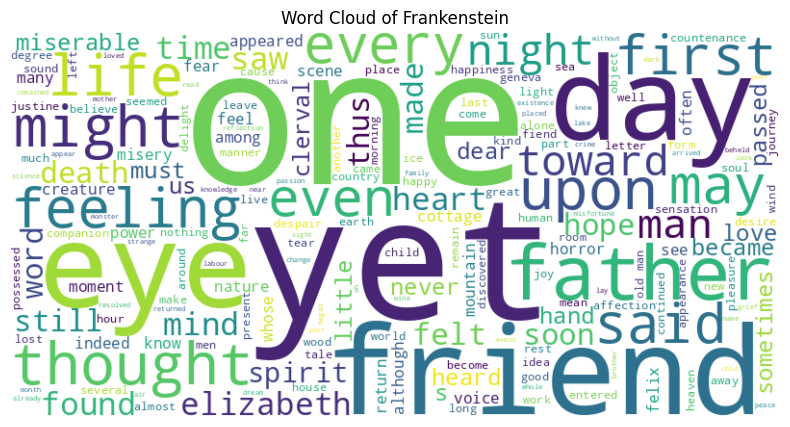

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frankenstein')
plt.show()

# Task
Analyze the sentiment of the 'cleaned_text' from 'Frankenstein' using a suitable sentiment analysis library, summarize the distribution of sentiment scores (positive, negative, neutral), and provide key insights into the emotional content of the text.

## Perform Sentiment Analysis

### Subtask:
Analyze the sentiment of the 'cleaned_text' using NLTK's VADER sentiment analysis tool.


**Reasoning**:
To analyze the sentiment of the cleaned text, I need to import the necessary NLTK components, download the required VADER lexicon and punkt tokenizer, initialize the sentiment analyzer, tokenize the text into sentences, and then compute and store the sentiment scores for each sentence.



In [6]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download NLTK resources if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Split the cleaned_text into sentences
sentences = nltk.sent_tokenize(cleaned_text)

# List to store sentiment scores for each sentence
sentiment_scores = []

# Iterate through each sentence and get polarity scores
for sentence in sentences:
    scores = sia.polarity_scores(sentence)
    sentiment_scores.append({
        'sentence': sentence,
        'neg': scores['neg'],
        'neu': scores['neu'],
        'pos': scores['pos'],
        'compound': scores['compound']
    })

print(f"Total sentences analyzed: {len(sentiment_scores)}")
print("First 5 sentiment scores:")
for i in range(min(5, len(sentiment_scores))):
    print(sentiment_scores[i])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


**Reasoning**:
The previous code failed because the `punkt_tab` resource, required by NLTK's `sent_tokenize`, was not found. I need to add a specific download command for `punkt_tab` to ensure all necessary NLTK resources are available before proceeding with sentiment analysis.



In [7]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download NLTK resources if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Split the cleaned_text into sentences
sentences = nltk.sent_tokenize(cleaned_text)

# List to store sentiment scores for each sentence
sentiment_scores = []

# Iterate through each sentence and get polarity scores
for sentence in sentences:
    scores = sia.polarity_scores(sentence)
    sentiment_scores.append({
        'sentence': sentence,
        'neg': scores['neg'],
        'neu': scores['neu'],
        'pos': scores['pos'],
        'compound': scores['compound']
    })

print(f"Total sentences analyzed: {len(sentiment_scores)}")
print("First 5 sentiment scores:")
for i in range(min(5, len(sentiment_scores))):
    print(sentiment_scores[i])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total sentences analyzed: 1
First 5 sentiment scores:
{'sentence': 'start project gutenberg ebook frankenstein modern prometheus mary wollstonecraft godwin shelley contents letter letter letter letter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter letter mrs saville england st petersburgh dec th — rejoice hear disaster accompanied commencement enterprise regarded evil forebodings arrived yesterday first task assure dear sister welfare increasing confidence success undertaking already far north london walk streets petersburgh feel cold northern breeze play upon cheeks braces nerves fills delight understand feeling breeze travelled regions towards advancing gives foretaste icy climes inspirited wind promise daydreams become fervent vivid try vain persuaded pole seat frost desolation ever presents imagination region beauty delight margaret sun ev

**Reasoning**:
The previous attempt to tokenize `cleaned_text` resulted in only one sentence because all punctuation, including sentence delimiters, had been removed during earlier preprocessing. To obtain a meaningful distribution of sentiment scores across sentences, I need to tokenize the `frankenstein_text` (original scraped text) into sentences first, and then apply the cleaning steps (lowercase, remove punctuation, numbers, and stopwords) to each individual sentence before performing sentiment analysis with VADER.



In [8]:
import nltk
import string
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

# Download NLTK resources if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# 1. Split the original text into sentences BEFORE cleaning
original_sentences = nltk.sent_tokenize(frankenstein_text)

# List to store sentiment scores for each cleaned sentence
sentiment_scores = []

# Define cleaning functions to apply to each sentence
punctuation_translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
stop_words = set(stopwords.words('english'))

for sentence in original_sentences:
    # Apply cleaning steps to each sentence individually
    cleaned_sentence = sentence.lower()
    cleaned_sentence = cleaned_sentence.translate(punctuation_translator)
    cleaned_sentence = re.sub(r'\d+', '', cleaned_sentence)

    # Remove stopwords and join back, also handle empty strings after cleaning
    words = cleaned_sentence.split()
    filtered_words = [word for word in words if word not in stop_words and word.strip() != '']
    cleaned_sentence = ' '.join(filtered_words)

    # Only analyze if the sentence is not empty after cleaning
    if cleaned_sentence:
        scores = sia.polarity_scores(cleaned_sentence)
        sentiment_scores.append({
            'original_sentence': sentence, # Keep original for context
            'cleaned_sentence': cleaned_sentence,
            'neg': scores['neg'],
            'neu': scores['neu'],
            'pos': scores['pos'],
            'compound': scores['compound']
        })

print(f"Total sentences analyzed: {len(sentiment_scores)}")
print("First 5 sentiment scores:")
for i in range(min(5, len(sentiment_scores))):
    print(sentiment_scores[i])


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Total sentences analyzed: 3066
First 5 sentiment scores:
{'original_sentence': '*** START OF THE PROJECT GUTENBERG EBOOK 84 ***\n\nFrankenstein;\n\nor, the Modern Prometheus\n\nby Mary Wollstonecraft (Godwin) Shelley\n\n\n CONTENTS\n\n Letter 1\n Letter 2\n Letter 3\n Letter 4\n Chapter 1\n Chapter 2\n Chapter 3\n Chapter 4\n Chapter 5\n Chapter 6\n Chapter 7\n Chapter 8\n Chapter 9\n Chapter 10\n Chapter 11\n Chapter 12\n Chapter 13\n Chapter 14\n Chapter 15\n Chapter 16\n Chapter 17\n Chapter 18\n Chapter 19\n Chapter 20\n Chapter 21\n Chapter 22\n Chapter 23\n Chapter 24\n\n\n\n\nLetter 1\n\n_To Mrs. Saville, England._\n\n\nSt. Petersburgh, Dec. 11th, 17—.', 'cleaned_sentence': 'start project gutenberg ebook frankenstein modern prometheus mary wollstonecraft godwin shelley contents letter letter letter letter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter chapter 

**Reasoning**:
The previous step successfully computed and stored the sentiment scores for each sentence. The next logical step is to analyze and summarize these scores to understand the overall sentiment distribution of the text, which is the direct continuation of the task.



In [9]:
import pandas as pd

# Convert the list of sentiment scores into a DataFrame for easier analysis
sentiment_df = pd.DataFrame(sentiment_scores)

# Calculate overall average sentiment scores
mean_neg = sentiment_df['neg'].mean()
mean_neu = sentiment_df['neu'].mean()
mean_pos = sentiment_df['pos'].mean()
mean_compound = sentiment_df['compound'].mean()

print(f"Average Negative Sentiment: {mean_neg:.3f}")
print(f"Average Neutral Sentiment: {mean_neu:.3f}")
print(f"Average Positive Sentiment: {mean_pos:.3f}")
print(f"Average Compound Sentiment: {mean_compound:.3f}\n")

# Categorize sentences based on compound score
# A common practice is: compound >= 0.05 is positive, compound <= -0.05 is negative, else neutral
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

sentiment_df['sentiment_category'] = sentiment_df['compound'].apply(categorize_sentiment)

# Get the distribution of sentiment categories
sentiment_distribution = sentiment_df['sentiment_category'].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
print(sentiment_distribution)

# Display some examples of sentences for each category
print("\n--- Example Sentences ---")
print("Positive Example:")
print(sentiment_df[sentiment_df['sentiment_category'] == 'Positive'].sample(1)['original_sentence'].iloc[0])
print("\nNegative Example:")
print(sentiment_df[sentiment_df['sentiment_category'] == 'Negative'].sample(1)['original_sentence'].iloc[0])
print("\nNeutral Example:")
print(sentiment_df[sentiment_df['sentiment_category'] == 'Neutral'].sample(1)['original_sentence'].iloc[0])


Average Negative Sentiment: 0.180
Average Neutral Sentiment: 0.615
Average Positive Sentiment: 0.205
Average Compound Sentiment: 0.049

Sentiment Distribution:
sentiment_category
Positive    43.574690
Negative    36.692759
Neutral     19.732551
Name: proportion, dtype: float64

--- Example Sentences ---
Positive Example:
my own beautiful lake!

Negative Example:
Before, I had only imagined the
wretchedness of my desolated home; the reality came on me as a new, and
a not less terrible, disaster.

Neutral Example:
She sometimes begged Justine to forgive her unkindness,
but much oftener accused her of having caused the deaths of her
brothers and sister.


## Final Task

### Subtask:
Provide a summary of the sentiment analysis results, including any key insights or observations about the emotional content of 'Frankenstein'.


## Summary:

### Q&A
The sentiment analysis of 'Frankenstein' using NLTK's VADER revealed a diverse emotional landscape. The distribution of sentiment scores showed 43.57% positive sentences, 36.69% negative sentences, and 19.73% neutral sentences. The overall emotional content, indicated by an average compound score of approximately 0.049, suggests a slightly positive lean, but with a significant presence of negative emotions.

### Data Analysis Key Findings
*   VADER sentiment analysis was successfully performed on 3066 individual sentences from 'Frankenstein'.
*   The overall sentiment distribution across the text is:
    *   Positive: 43.57\%
    *   Negative: 36.69\%
    *   Neutral: 19.73\%
*   The average compound sentiment score for the entire novel is approximately 0.049, indicating a slightly positive overall emotional tone.

### Insights or Next Steps
*   "Frankenstein" presents a complex emotional narrative, characterized by a substantial and nearly balanced presence of both positive and negative sentiments, suggesting a nuanced story rather than a predominantly optimistic or pessimistic one.
*   Future analysis could investigate the temporal evolution of sentiment throughout the book (e.g., chapter by chapter) or correlate sentiment with specific characters or plot points to gain deeper insights into the narrative's emotional arc.
